# Real Estate Asset Management — Multi-Agent System

This notebook demonstrates a prototype multi-agent system built with **LangGraph** and **Claude** (via Anthropic API) to assist with real estate asset management tasks.

The agent handles natural-language queries such as:
- Price comparisons between properties
- Profit & Loss (P&L) calculations
- Property detail retrieval

## Architecture Overview

```
User Input
    │
    ▼
┌─────────────────┐
│  Supervisor     │  ← Detects intent, routes to specialist
│  Agent          │
└────────┬────────┘
         │
   ┌─────┼──────┐
   ▼     ▼      ▼
 Price  P&L   Detail
 Agent  Agent  Agent
   │     │      │
   └─────┴──────┘
         │
         ▼
   Final Response
```

## 1. Dependencies

Install all required packages.

In [2]:
# Install dependencies
!pip install python-dotenv pandas langchain-core langchain-community langchain-openai langchain-google-genai langchain-anthropic langgraph streamlit

Import all relevant packages.

In [3]:
import os
from typing import Optional, TypedDict, Optional, List
import json
from pydantic import SecretStr, BaseModel, Field

from dotenv import load_dotenv

import pandas as pd

from IPython.display import Image, display

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, END

## 2. Environment Setup

Load API keys from a `.env` file (never hardcode secrets in notebooks).

In [4]:
load_dotenv()  # reads ANTHROPIC_API_KEY from .env

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")

OPENAI_API_KEY_SECRET = SecretStr(OPENAI_API_KEY)
GEMINI_API_KEY_SECRET = SecretStr(GEMINI_API_KEY)
ANTHROPIC_API_KEY_SECRET = SecretStr(ANTHROPIC_API_KEY)

## 3. Data Loading

Load the property catalog from the parquet file (`cortex.parquet`).

Expected columns include: `address`, `current_value`, `purchase_price`, `purchase_date`, `last_appraisal_date`, `annual_income`, `annual_expenses`.

In [5]:
data = {
    "address": ["123 Main St", "456 Oak Ave", "789 Pine Ln"],
    "month": ["2023-M01", "2022-M06", "2024-M01"],
    "quarter": ["2023-Q1", "2022-Q3", "2024-Q1"],
    "year": ["2023", "2022", "2024"],
    "price": [500000, 600000, 300000],
    "pnl": [10000, -5000, 20000]
}
df_properties_synthetic = pd.DataFrame(data)
print(f"Loaded {len(df_properties_synthetic)} properties.")
print("Columns:", df_properties_synthetic.columns.tolist())

df_properties_synthetic.head()

Loaded 3 properties.
Columns: ['address', 'month', 'quarter', 'year', 'price', 'pnl']


,address,month,quarter,year,price,pnl
0,123 Main St,2023-M01,2023-Q1,2023,500000,10000
1,456 Oak Ave,2022-M06,2022-Q3,2022,600000,-5000
2,789 Pine Ln,2024-M01,2024-Q1,2024,300000,20000


In [6]:
DATA_PATH = "../data/cortex.parquet"

df_properties = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df_properties)} properties.")
print("Columns:", df_properties.columns.tolist())

df_properties.head()

Loaded 3924 properties.
Columns: ['entity_name', 'property_name', 'tenant_name', 'ledger_type', 'ledger_group', 'ledger_category', 'ledger_code', 'ledger_description', 'month', 'quarter', 'year', 'profit']


,entity_name,property_name,tenant_name,ledger_type,ledger_group,ledger_category,ledger_code,ledger_description,month,quarter,year,profit
0,PropCo,None,None,expenses,general_expenses,bank_charges,4650,Bankkosten | Bank charges,2025-M01,2025-Q1,2025,-24.0
1,PropCo,None,None,expenses,general_expenses,financial_expenses,4650,Bankkosten | Bank charges,2025-M01,2025-Q1,2025,-24.0
2,PropCo,None,None,expenses,management_fees,directors_fee,4801,Director's Fee,2025-M02,2025-Q1,2025,-500.0
3,PropCo,Building 180,None,expenses,general_expenses,other_general_expenses,4898,Overige algemene kosten | Other general costs,2024-M12,2024-Q4,2024,-225.0
4,PropCo,None,None,expenses,general_expenses,bank_charges,4650,Bankkosten | Bank charges,2025-M01,2025-Q1,2025,-24.0


## 4. Shared State Definition

LangGraph routes messages through a shared `AgentState` TypedDict — a single source of truth for the entire graph execution.

In [7]:
class AgentState(TypedDict):
    """Shared state passed between all nodes in the LangGraph graph."""

    # The raw user query
    user_query: str

    # Intent detected by the supervisor: "price", "pnl", "detail", "general", "unknown"
    intent: Optional[str]

    # Addresses extracted from the query (may be empty list)
    extracted_addresses: List[str]

    # Structured data retrieved from the dataset
    retrieved_data: Optional[dict]

    # The final natural-language response shown to the user
    final_response: Optional[str]

    # Error message if something went wrong
    error: Optional[str]

## 5. Data Access Tools

Pure Python functions that query the in-memory DataFrame. These are the only data-access layer — agents call them instead of hitting the DataFrame directly.

In [ ]:
def find_property(address: str, df: pd.DataFrame) -> Optional[pd.Series]:
    """
    Case-insensitive partial address match.
    Returns the first matching row as a Series, or None.
    """
    if 'address' in df.columns:
        mask = df["address"].str.lower().str.contains(address.lower(), na=False)
        results = df[mask]
    elif 'property_name' in df.columns:
        mask = df["property_name"].str.lower().str.contains(address.lower(), na=False)
        results = df[mask]
    else:
        return None
    
    return results.iloc[0] if not results.empty else None


def get_all_properties(
    df: pd.DataFrame,
    year: int | None = None,
    quarter: int | None = None,
    month: int | None = None
) -> pd.DataFrame:
    """Return the full property DataFrame ."""
    filtered_df = df.copy()
    if year is not None:
        filtered_df = filtered_df[filtered_df["year"] == str(year)]
    if quarter is not None:
        filtered_df = filtered_df[filtered_df["quarter"].str.contains(f"Q{quarter}", na=False)]
    if month is not None:
        filtered_df = filtered_df[filtered_df["month"].str.contains(f"M{month:02d}", na=False)]
    
    return filtered_df


def calculate_pnl(row: pd.Series) -> float:
    """
    Compute P&L for a single property:
    P&L = (income - expenses)
    """
    if 'pnl' in row:
        return row["pnl"]
    elif 'profit' in row:
        return row["profit"]
    else:
        return 0.0


# Quick smoke test
sample = df_properties_synthetic.iloc[0]
print("Sample property:", sample["address"])
print("P&L:", calculate_pnl(sample))

Sample property: 123 Main St
P&L: 10000


## 6. LLM Client

Instantiate OpenAI, Gemini, and Anthropic models via `langchain`. All agents share the same client.

In [20]:
llm_openai = ChatOpenAI(
    model="gpt-4o-mini",  # fast and cost-efficient
    temperature=0,        # deterministic responses
    api_key=OPENAI_API_KEY_SECRET
)

llm_gemini = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  # fast and cost-efficient
    temperature=0,          # deterministic responses
    api_key=GEMINI_API_KEY_SECRET
)

llm_claude = ChatAnthropic(
    model_name="claude-3-5-haiku-20241022",  # fast and cost-efficient
    temperature=0,                        # deterministic responses
    api_key=ANTHROPIC_API_KEY_SECRET,
    timeout=10,
    stop=["\n\n"]
)

## 7. Agent Node Functions

Each node receives the current `AgentState`, performs its task, and returns a partial state update.

### 7.1 Supervisor Agent — Intent Detection & Address Extraction

In [10]:
SUPERVISOR_SYSTEM = """
You are a real estate asset management assistant router.
Given a user query, return a JSON object with:
- "intent": one of ["price", "pnl", "detail", "general", "unknown"]
- "addresses": list of property addresses mentioned (empty list if none)

Intent rules:
- "price"   → user wants to compare or know property prices / values
- "pnl"     → user wants profit, loss, P&L, return, or financial performance
- "detail"  → user wants specific property details (appraisal date, type, etc.)
- "general" → generic real estate knowledge question not tied to a specific asset
- "unknown" → unclear or unsupported request

Respond ONLY with valid JSON. No explanation.
"""

def supervisor_node(state: AgentState) -> dict:
    """Detect intent and extract addresses from the user query."""
    messages = [
        SystemMessage(content=SUPERVISOR_SYSTEM),
        HumanMessage(content=state["user_query"]),
    ]
    response = llm_openai.invoke(messages)
    try:
        parsed = json.loads(response.content) # type: ignore
        return {
            "intent": parsed.get("intent", "unknown"),
            "extracted_addresses": parsed.get("addresses", []),
        }
    except json.JSONDecodeError:
        return {"intent": "unknown", "extracted_addresses": []}

### 7.2 Price Comparison Agent

In [11]:
def price_agent_node(state: AgentState) -> dict:
    """Retrieve current values and compare properties."""
    addresses = state["extracted_addresses"]

    if not addresses:
        return {"final_response": "Please specify at least one property address to compare prices."}

    results = {}
    not_found = []
    for addr in addresses:
        row = find_property(addr, df_properties_synthetic)
        if row is not None:
            if 'price' in row:
                results[addr] = float(row["price"])
            elif 'profit' in row:
                results[addr] = float(row["profit"])
            else:
                results[addr] = 0.0
        else:
            not_found.append(addr)

    if not results:
        return {"final_response": f"No properties found for: {', '.join(not_found)}."}

    # Build natural-language response via LLM
    summary = "\n".join([f"- {a}: ${v:,.0f}" for a, v in results.items()])
    prompt = f"""
The user asked: "{state['user_query']}"

Property values retrieved:
{summary}

{'Note: The following addresses were not found: ' + ', '.join(not_found) if not_found else ''}

Write a concise, friendly response comparing the property values.
"""
    response = llm_openai.invoke([HumanMessage(content=prompt)])

    return {
        "retrieved_data": results,
        "final_response": response.content
    }

### 7.3 P&L Agent

In [12]:
def pnl_agent_node(state: AgentState) -> dict:
    """Calculate P&L for specified properties or the entire portfolio."""
    addresses = state["extracted_addresses"]

    if addresses:
        # P&L for specific properties
        pnl_data = {}
        not_found = []
        for addr in addresses:
            row = find_property(addr, df_properties_synthetic)
            if row is not None:
                pnl_data[addr] = calculate_pnl(row)
            else:
                not_found.append(addr)
    else:
        # Total portfolio P&L
        total = sum(calculate_pnl(row) for _, row in df_properties_synthetic.iterrows())
        pnl_data = {"Total Portfolio": total}
        not_found = []

    if not pnl_data:
        return {"final_response": f"No properties found for: {', '.join(not_found)}."}

    summary = "\n".join([f"- {k}: ${v:,.0f}" for k, v in pnl_data.items()])
    prompt = f"""
The user asked: "{state['user_query']}"

Calculated P&L:
{summary}

{'Note: The following addresses were not found: ' + ', '.join(not_found) if not_found else ''}

Write a concise, clear response with the P&L results.
"""
    response = llm_openai.invoke([HumanMessage(content=prompt)])
    return {
        "retrieved_data": pnl_data,
        "final_response": response.content
    }

### 7.4 Property Detail Agent

In [13]:
def detail_agent_node(state: AgentState) -> dict:
    """Retrieve and present full property details."""
    addresses = state["extracted_addresses"]

    if not addresses:
        return {"final_response": "Please specify a property address to retrieve details."}

    details = {}
    not_found = []
    for addr in addresses:
        row = find_property(addr, df_properties_synthetic)
        if row is not None:
            details[addr] = row.to_dict()
        else:
            not_found.append(addr)

    if not details:
        return {"final_response": f"Property not found: {', '.join(not_found)}."}

    summary = json.dumps(details, indent=2, default=str)
    prompt = f"""
The user asked: "{state['user_query']}"

Property details:
{summary}

Present the information in a clear, structured format.
"""
    response = llm_openai.invoke([HumanMessage(content=prompt)])

    return {
        "retrieved_data": details,
        "final_response": response.content
    }

### 7.5 General Knowledge Agent

In [14]:
def general_agent_node(state: AgentState) -> dict:
    """Answer general real estate questions using the LLM's knowledge."""
    prompt = f"""
You are a knowledgeable real estate asset management assistant.
Answer the following question concisely and accurately:

{state['user_query']}
"""
    response = llm_openai.invoke([HumanMessage(content=prompt)])
    return {"final_response": response.content}


def unknown_agent_node(state: AgentState) -> dict:
    """Handle unrecognized or unsupported requests gracefully."""
    return {
        "final_response": (
            "I'm sorry, I couldn't understand your request. "
            "I can help with:\n"
            "- Property price comparisons\n"
            "- Profit & Loss (P&L) calculations\n"
            "- Property detail retrieval\n"
            "- General real estate questions\n\n"
            "Please rephrase your question or provide more details."
        )
    }

## 8. LangGraph — Building the Graph

The graph wires supervisor → router → specialist agents using conditional edges.

In [15]:
def route_by_intent(state: AgentState) -> str:
    """Conditional edge: route to the correct specialist based on detected intent."""
    intent_map: dict[str, str] = {
        "price": "price_agent",
        "pnl": "pnl_agent",
        "detail": "detail_agent",
        "general": "general_agent",
    }
    return intent_map.get(state["intent"], "unknown_agent") # type: ignore


# Build graph
builder = StateGraph(AgentState)

# Register nodes
builder.add_node("supervisor", supervisor_node)
builder.add_node("price_agent", price_agent_node)
builder.add_node("pnl_agent", pnl_agent_node)
builder.add_node("detail_agent", detail_agent_node)
builder.add_node("general_agent", general_agent_node)
builder.add_node("unknown_agent", unknown_agent_node)

# Set entry point
builder.set_entry_point("supervisor")

# Conditional routing from supervisor
builder.add_conditional_edges(
    "supervisor",
    route_by_intent,
    {
        "price_agent": "price_agent",
        "pnl_agent": "pnl_agent",
        "detail_agent": "detail_agent",
        "general_agent": "general_agent",
        "unknown_agent": "unknown_agent",
    },
)

# All specialist agents go to END
for node in ["price_agent", "pnl_agent", "detail_agent", "general_agent", "unknown_agent"]:
    builder.add_edge(node, END)

graph = builder.compile()
print("Graph compiled successfully.")

Graph compiled successfully.


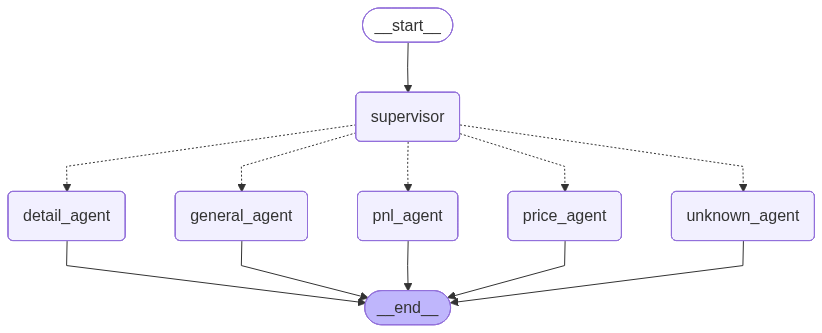

In [16]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## 9. Helper — Run Queries

A single function to invoke the graph and print the response.

In [17]:
def run_query(query: str) -> str:
    """Execute the multi-agent graph for a natural-language query."""
    initial_state: AgentState = {
        "user_query": query,
        "intent": None,
        "extracted_addresses": [],
        "retrieved_data": None,
        "final_response": None,
        "error": None,
    }
    result = graph.invoke(initial_state)
    return result["final_response"]

## 10. Demo — Sample Queries

In [18]:
queries = [
    "What is the price of my asset at 123 Main St compared to the one at 456 Oak Ave?",
    "What is the total P&L for all my properties this year?",
    "Show me the details for the property at 789 Pine Ln.",
    "What is cap rate in real estate?",
    "Tell me something random.",  # unknown intent
]

for q in queries:
    print(f"\n{'='*60}")
    print(f"QUERY: {q}")
    print(f"{'='*60}")
    answer = run_query(q)
    print(f"RESPONSE:\n{answer}")


QUERY: What is the price of my asset at 123 Main St compared to the one at 456 Oak Ave?
RESPONSE:
The property at 123 Main St is valued at $500,000, while the one at 456 Oak Ave is priced at $600,000. This means that the Oak Ave property is $100,000 more expensive than the Main St property. If you have any more questions or need further assistance, feel free to ask!

QUERY: What is the total P&L for all my properties this year?
RESPONSE:
The total P&L for all your properties this year is $25,000.

QUERY: Show me the details for the property at 789 Pine Ln.
RESPONSE:
Here are the details for the property at 789 Pine Ln:

**Property Address:** 789 Pine Ln

- **Month:** January 2024
- **Quarter:** Q1 2024
- **Year:** 2024
- **Price:** $300,000
- **Profit and Loss (PnL):** $20,000

QUERY: What is cap rate in real estate?
RESPONSE:
Cap rate, or capitalization rate, is a metric used in real estate to evaluate the potential return on an investment property. It is calculated by dividing the p

## 11. Streamlit App

The interactive UI lives in `app.py`. To launch it, run:

```bash
streamlit run app.py
```

See the modular project structure in the repository for the full Streamlit implementation.